# Load baseline model

Choose a saved baseline run, load its checkpoint, verify save/load behavior, plot training curves, and inspect validation predictions.


In [16]:
import sys
from pathlib import Path

project_root = Path('..').resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import json
import tempfile
from pathlib import Path

import keras
import matplotlib.pyplot as plt
import numpy as np

from src.data.freihand import FreiHand, SPLIT_SEED, SPLIT_VALIDATION_FRACTION
from src.evaluation.metrics import evaluate_model, sample_mpke
from src.evaluation.overlays import prediction_grid, save_figure
from src.evaluation.training_curves import load_history, plot_training_curves


## Choose run


In [17]:
BASELINE_RUN = 'baseline-model-1'
AVAILABLE_BASELINES = ('baseline-model-1', 'baseline-model-2')

if BASELINE_RUN not in AVAILABLE_BASELINES:
    raise ValueError(f'Unknown baseline run: {BASELINE_RUN}')

run_dir = project_root / 'models' / BASELINE_RUN
checkpoint_path = run_dir / 'best.keras'
config_path = project_root / 'logs' / BASELINE_RUN / 'config.json'
evaluation_path = project_root / 'artifacts' / BASELINE_RUN / 'evaluation.json'

if not config_path.exists():
    raise FileNotFoundError(f'Missing run config: {config_path}')
if not checkpoint_path.exists():
    raise FileNotFoundError(f'Missing checkpoint: {checkpoint_path}')

config = json.loads(config_path.read_text())
input_size = int(config.get('input_shape', [224])[0])
print(f'Run:        {BASELINE_RUN}')
print(f'Model ID:   {config.get("model_id", config.get("model"))}')
print(f'Checkpoint: {checkpoint_path}')
print(f'Input size: {input_size}')
print(json.dumps(config, indent=2))


Run:        baseline-model-1
Model ID:   baseline-model-1
Checkpoint: /Users/victor/Projects/code/hand-pose-estimation/models/baseline-model-1/best.keras
Input size: 224
{
  "run_name": "baseline-model-1",
  "epochs": 30,
  "batch_size": 32,
  "learning_rate": 0.001,
  "validation_fraction": 0.1,
  "seed": 42,
  "n_train": 29304,
  "n_val": 3256,
  "input_shape": [
    224,
    224,
    3
  ],
  "loss": "mse",
  "metrics": [
    "mae"
  ],
  "optimizer": "adam",
  "model_id": "baseline-model-1",
  "model": "baseline-model-1",
  "representation": "coordinate"
}


## Training curves


Saved figure: reports/figures/baseline-model-1_training_curves.png


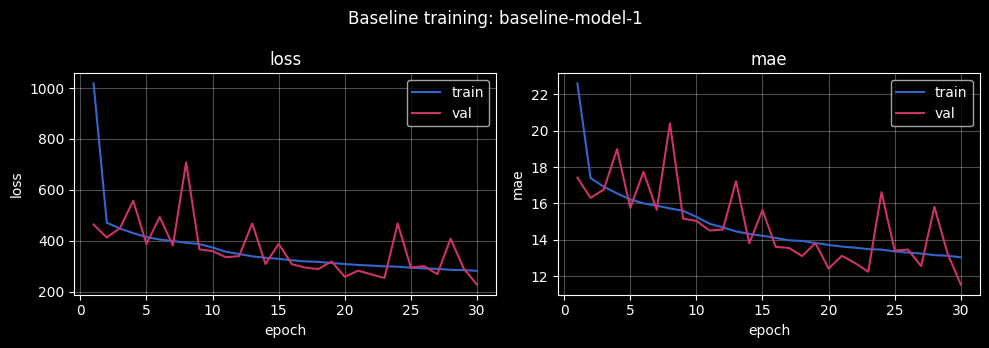

In [18]:
history = load_history(BASELINE_RUN)
fig = plot_training_curves(history, suptitle=f'Baseline training: {BASELINE_RUN}')
saved_path = save_figure(fig, f'{BASELINE_RUN}_training_curves')
print(f'Saved figure: {saved_path.relative_to(project_root)}')
plt.show()


## Load and verify checkpoint


In [19]:
model = keras.models.load_model(checkpoint_path)
model.summary()

dummy = np.random.default_rng(0).random((4, input_size, input_size, 3), dtype=np.float32)
expected = model.predict(dummy, verbose=0)

with tempfile.TemporaryDirectory() as tmp:
    roundtrip_path = Path(tmp) / 'roundtrip.keras'
    model.save(roundtrip_path)
    reloaded = keras.models.load_model(roundtrip_path)
    actual = reloaded.predict(dummy, verbose=0)

assert np.array_equal(expected, actual), 'Round-trip predictions do not match'
print('Round-trip OK: reloaded model produces identical predictions.')


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 42)             │        10,794 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 412,992 (1.58 MB)

 Trainable params: 137,514 (537.16 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 275,030 (1.05 MB)

Round-trip OK: reloaded model produces identical predictions.


## Validation sample overlays


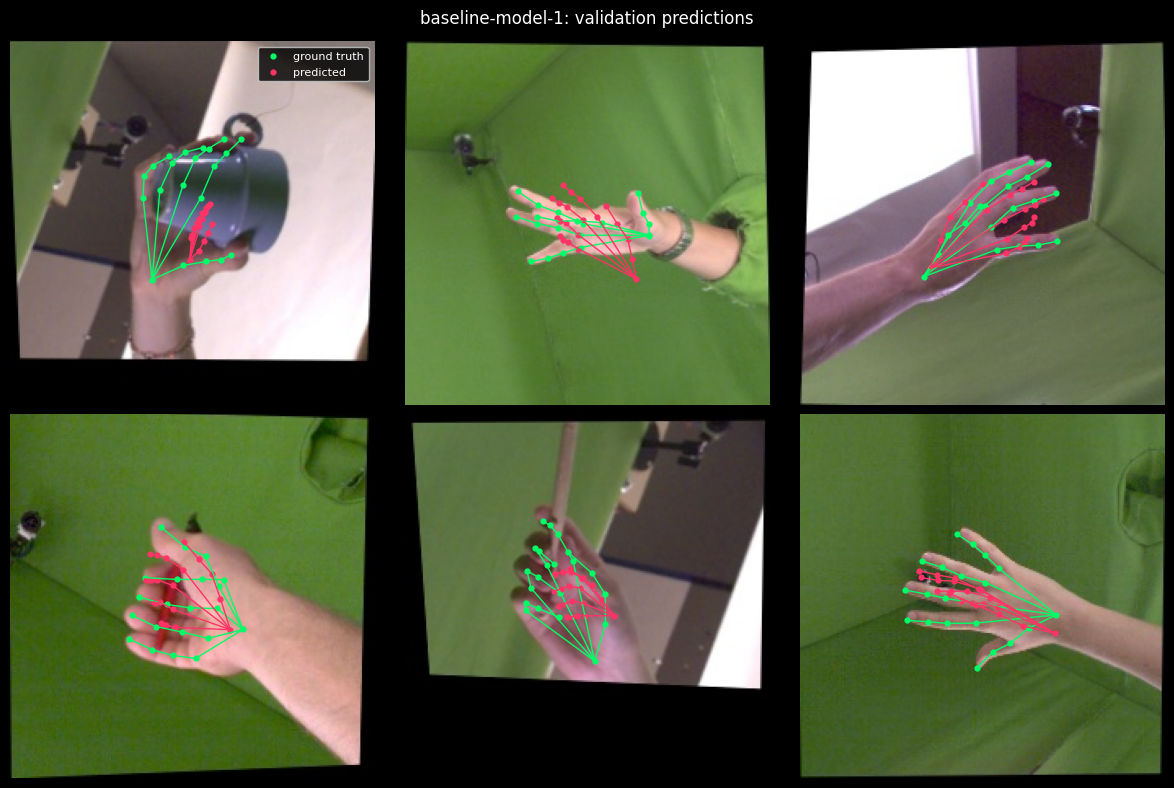

In [20]:
dataset = FreiHand()
dataset.validate()
_, val_idx = dataset.train_validation_split(
    validation_fraction=SPLIT_VALIDATION_FRACTION,
    seed=SPLIT_SEED,
)

sample_ids = val_idx[:6]
images, ground_truth = dataset.load_batch(
    sample_ids,
    image_size=(input_size, input_size),
    flatten_keypoints=False,
)
predictions = model.predict(images, verbose=0).reshape(-1, 21, 2)

fig = prediction_grid(
    images,
    ground_truth,
    predictions,
    ncols=3,
    suptitle=f'{BASELINE_RUN}: validation predictions',
)
plt.show()


## Full validation metric


In [21]:
val_ds = dataset.tf_dataset(
    indices=val_idx,
    batch_size=64,
    image_size=(input_size, input_size),
    flatten_keypoints=True,
)
metrics = evaluate_model(model, val_ds, include_representative_indices=True)
print(metrics)


{'mpke_px': 18.099241256713867, 'median_sample_mpke_px': 17.22201156616211, 'p75_sample_mpke_px': 21.537906646728516, 'p90_sample_mpke_px': 26.320396423339844, 'p95_sample_mpke_px': 30.056838989257812, 'max_sample_mpke_px': 75.98968505859375, 'representative_indices': {'best': 3089, 'median': 125, 'p90': 2135, 'worst': 2984}, 'n_samples': 3256}


## Representative samples


Saved figure: reports/figures/baseline-model-1_representative_predictions.png


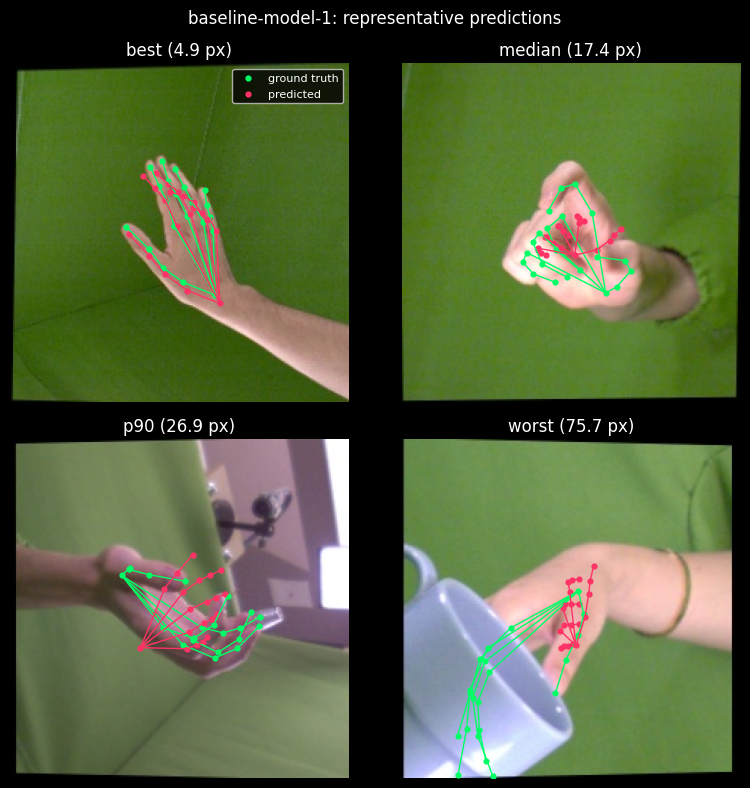

In [22]:
if evaluation_path.exists():
    evaluation = json.loads(evaluation_path.read_text())
    representative = evaluation['metrics']['representative_indices']
else:
    representative = metrics['representative_indices']

labels = ['best', 'median', 'p90', 'worst']
sample_ids = np.array([val_idx[representative[label]] for label in labels])
images, ground_truth = dataset.load_batch(
    sample_ids,
    image_size=(input_size, input_size),
    flatten_keypoints=False,
)
predictions = model.predict(images, verbose=0).reshape(-1, 21, 2)
errors = sample_mpke(predictions, ground_truth)
titles = [f'{label} ({error:.1f} px)' for label, error in zip(labels, errors)]

fig = prediction_grid(
    images,
    ground_truth,
    predictions,
    titles=titles,
    ncols=2,
    suptitle=f'{BASELINE_RUN}: representative predictions',
)
saved_path = save_figure(fig, f'{BASELINE_RUN}_representative_predictions')
print(f'Saved figure: {saved_path.relative_to(project_root)}')
plt.show()
